# SiLU (Swish): From Scratch

**SiLU (Sigmoid Linear Unit)** is the activation function of choice for many modern LLMs. It was discovered by Google Brain researchers using Neural Architecture Search.

In this tutorial, we will:
1. Implement SiLU from scratch.
2. Visualize it and its derivative.
3. Compare it with ReLU.

## 1. Implementation

$$ \text{SiLU}(x) = x \cdot \sigma(x) $$

where $\sigma(x) = \frac{1}{1 + e^{-x}}$ is the sigmoid function.

In [1]:
import torch
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

def silu(x):
    return x * sigmoid(x)

# Test values
x = torch.linspace(-5, 5, 100, requires_grad=True)
y = silu(x)

## 2. Visualization

Let's plot SiLU and its gradient. Notice how it looks like ReLU but is smooth at 0 and allows a small negative dip.

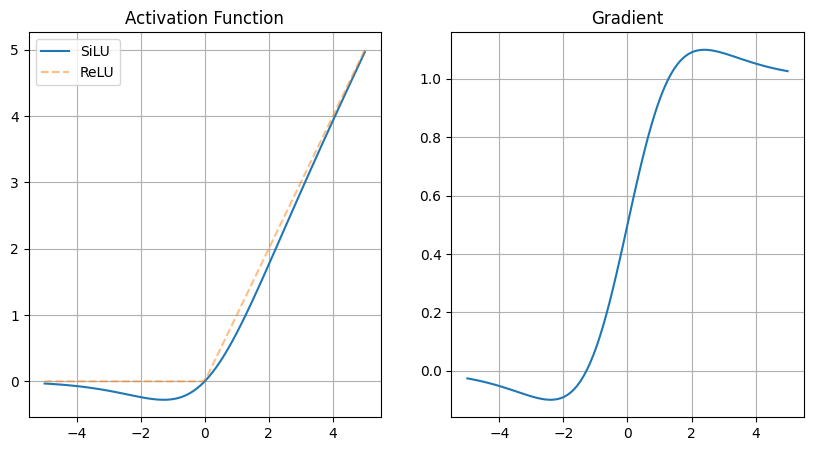

In [2]:
# Compute gradients
y.sum().backward()
grad = x.grad

plt.figure(figsize=(10, 5))

# Plot Function
plt.subplot(1, 2, 1)
plt.plot(x.detach(), y.detach(), label="SiLU")
plt.plot(x.detach(), torch.relu(x.detach()), '--', alpha=0.5, label="ReLU")
plt.title("Activation Function")
plt.legend()
plt.grid(True)

# Plot Gradient
plt.subplot(1, 2, 2)
plt.plot(x.detach(), grad.detach(), label="SiLU Gradient")
plt.title("Gradient")
plt.grid(True)

plt.show()

## 3. Why is it better?

1.  **Smoothness**: The curve is differentiable everywhere, unlike ReLU which has a kink at 0. This helps optimization.
2.  **Non-monotonic**: The small dip for negative values allows the model to capture more complex patterns and "un-fire" a neuron slightly.